In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv files

In [ ]:
# Load clean products data
products_df = pd.read_csv("../data/cleaned/products_cl.csv")

# Load quality checked orders data
orders_final = pd.read_csv("../data/quality_checked/orders_qu.csv")

# Load original brands data
brands = pd.read_csv("../data/original/brands.csv")

In [3]:
orders_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 40985 entries, 0 to 40984
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      40985 non-null  int64  
 1   created_date  40985 non-null  str    
 2   total_paid    40985 non-null  float64
 3   state         40985 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 1.3 MB


In [4]:
orderlines_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                53231 non-null  int64  
 1   id_order          53231 non-null  int64  
 2   product_id        53231 non-null  int64  
 3   product_quantity  53231 non-null  int64  
 4   sku               53231 non-null  str    
 5   unit_price        53231 non-null  float64
 6   date              53231 non-null  str    
dtypes: float64(1), int64(4), str(2)
memory usage: 2.8 MB


In [5]:

# products_final.info()

In [6]:
brands.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   short   187 non-null    str  
 1   long    187 non-null    str  
dtypes: str(2)
memory usage: 3.1 KB


  Discount Range  Number of Orders
0     0% or less              2496
1          1-10%              8118
2         11-20%             12536
3         21-30%              9163
4         31-40%              3322
5         41-50%              2011
6           >50%              3339


C:\Users\pakan\AppData\Local\Temp\ipykernel_10024\4232005955.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_counts, x='Discount Range', y='Number of Orders', palette='viridis')


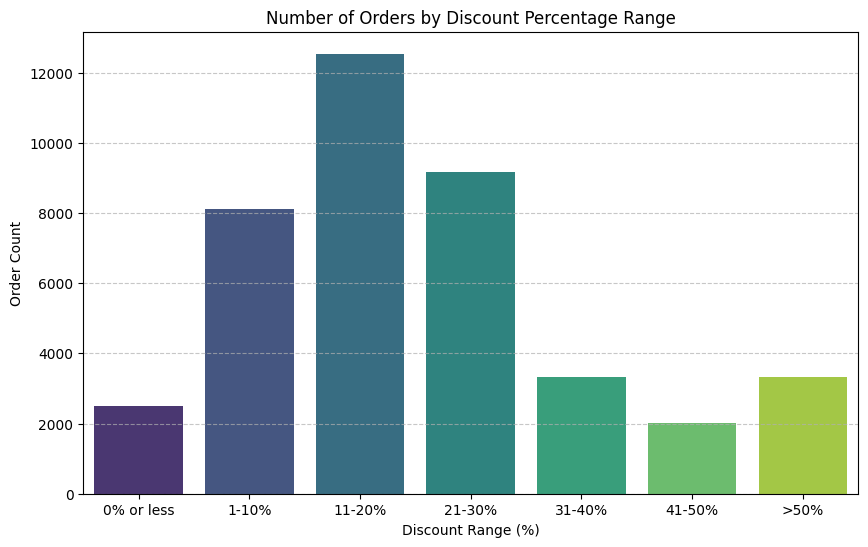

In [ ]:

# Step 1: Calculate total potential price (MSRP) per line item
# Merge orderlines with products to get the original price
products_final = orderlines_final.merge(products_final[['sku', 'price']], on='sku', how='left')

# Calculate the subtotal based on MSRP and the actual subtotal paid
products_final['total_msrp'] = products_final['product_quantity'] * products_final['price']
products_final['total_paid_line'] = products_final['product_quantity'] * products_final['unit_price']

# Step 2: Aggregate to the order level
order_discounts = products_final.groupby('id_order').agg({
    'total_msrp': 'sum',
    'total_paid_line': 'sum'
}).reset_index()

# Step 3: Calculate the discount percentage
# We use a small epsilon or check for zero to avoid division by zero
order_discounts['discount_amount'] = order_discounts['total_msrp'] - order_discounts['total_paid_line']
order_discounts['discount_pct'] = (order_discounts['discount_amount'] / order_discounts['total_msrp']) * 100

# Step 4: Clean data (filter out negative discounts or outliers if necessary)
# Usually, a negative discount means the item was sold for more than MSRP, which can happen.
# We'll round and bin the discounts for visualization
order_discounts['discount_bin'] = pd.cut(order_discounts['discount_pct'], 
                                         bins=[-float('inf'), 0, 10, 20, 30, 40, 50, 100], 
                                         labels=['0% or less', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '>50%'])

# Step 5: Count orders per discount bin
discount_counts = order_discounts['discount_bin'].value_counts().sort_index().reset_index()
discount_counts.columns = ['Discount Range', 'Number of Orders']

print(discount_counts)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=discount_counts, x='Discount Range', y='Number of Orders', palette='viridis')
plt.title('Number of Orders by Discount Percentage Range')
plt.xlabel('Discount Range (%)')
plt.ylabel('Order Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('orders_by_discount.png')
plt.show()

  discount_range  total_revenue  total_msrp_value  revenue_lost_to_discount
0    No Discount   2.078990e+07      2.025470e+07                -535199.59
1          1-10%   1.517060e+08      1.598171e+08                8111065.58
2         11-20%   2.136471e+08      2.505963e+08               36949170.72
3         21-30%   1.025887e+08      1.352112e+08               32622423.66
4         31-40%   1.360552e+07      2.058098e+07                6975453.33
5         41-50%   5.883396e+06      1.055649e+07                4673089.33
6           50%+   1.116219e+07      2.953977e+07               18377579.94


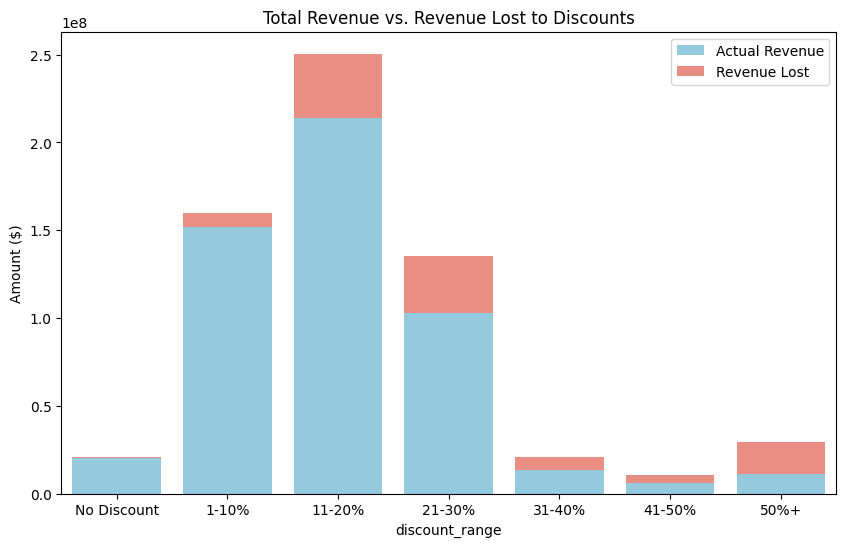

In [9]:
# Merge to get MSRP (price)
df = orderlines_final.merge(products_final[['sku', 'price']], on='sku', how='left')

# Calculate Revenue and potential "Loss" from discounts
df['total_revenue'] = df['product_quantity'] * df['unit_price']
df['total_msrp_value'] = df['product_quantity'] * df['price']

# Group by order to get the discount percentage per order
order_summary = df.groupby('id_order').agg({
    'total_revenue': 'sum',
    'total_msrp_value': 'sum'
}).reset_index()

# Calculate discount percentage
order_summary['discount_pct'] = (1 - (order_summary['total_revenue'] / order_summary['total_msrp_value'])) * 100

# Since we don't have 'cost', we'll use 'Revenue Contribution' as the metric.
# However, many businesses assume a baseline margin (e.g., 30% of MSRP). 
# Without a specific cost, I'll calculate 'Revenue vs MSRP' to show the impact on potential earnings.

# Binning
bins = [-100, 0, 10, 20, 30, 40, 50, 200]
labels = ['No Discount', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '50%+']
order_summary['discount_range'] = pd.cut(order_summary['discount_pct'], bins=bins, labels=labels)

# Aggregate
profit_impact = order_summary.groupby('discount_range').agg({
    'total_revenue': 'sum',
    'total_msrp_value': 'sum'
}).reset_index()

profit_impact['revenue_lost_to_discount'] = profit_impact['total_msrp_value'] - profit_impact['total_revenue']

print(profit_impact)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=profit_impact, x='discount_range', y='total_revenue', color='skyblue', label='Actual Revenue')
sns.barplot(data=profit_impact, x='discount_range', y='revenue_lost_to_discount', bottom=profit_impact['total_revenue'], color='salmon', label='Revenue Lost')
plt.title('Total Revenue vs. Revenue Lost to Discounts')
plt.ylabel('Amount ($)')
plt.legend()
plt.savefig('revenue_impact.png')

C:\Users\pakan\AppData\Local\Temp\ipykernel_10024\343108041.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette=colors)


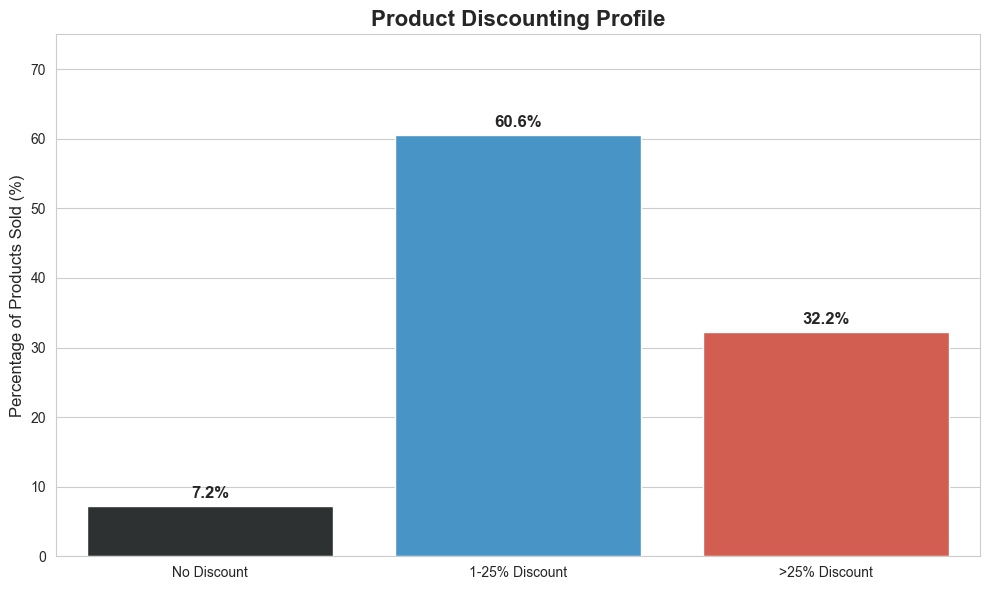

In [10]:

# Data based on the previous context provided
labels = ['No Discount', '1-25% Discount', '>25% Discount']
values = [7.2, 60.6, 32.2]
colors = ['#2e3131', '#3498db', '#e74c3c'] # Professional dark, blue, and red

# 1. Pie Chart for Discount Penetration
#plt.figure(figsize=(10, 7))
# plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0, 0), shadow=True)
# plt.title('Product Sales Distribution by Discount Level\n(Jan 2017 - March 2018)', fontsize=15, fontweight='bold')
# plt.tight_layout()
# plt.savefig('discount_penetration_pie.png')

# 2. Bar Chart for Presentation Clarity
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=labels, y=values, palette=colors)

# Adding value labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=12, fontweight='bold')

plt.title('Product Discounting Profile', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Products Sold (%)', fontsize=12)
plt.ylim(0, 75)
plt.tight_layout()
plt.savefig('discount_profile_bar.png')

plt.show()